- # **Quietly installs baccoemu**

In [1]:
pip install -q baccoemu

- # **Generates total matter spectrum**

Generating total matter linear power spectrum using baccoemu...
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
k range: 1.0e-04 to 5.0e+01 h/Mpc
Number of k points: 200
Peak power (total matter): 2.6e+04 h^-3 Mpc^3


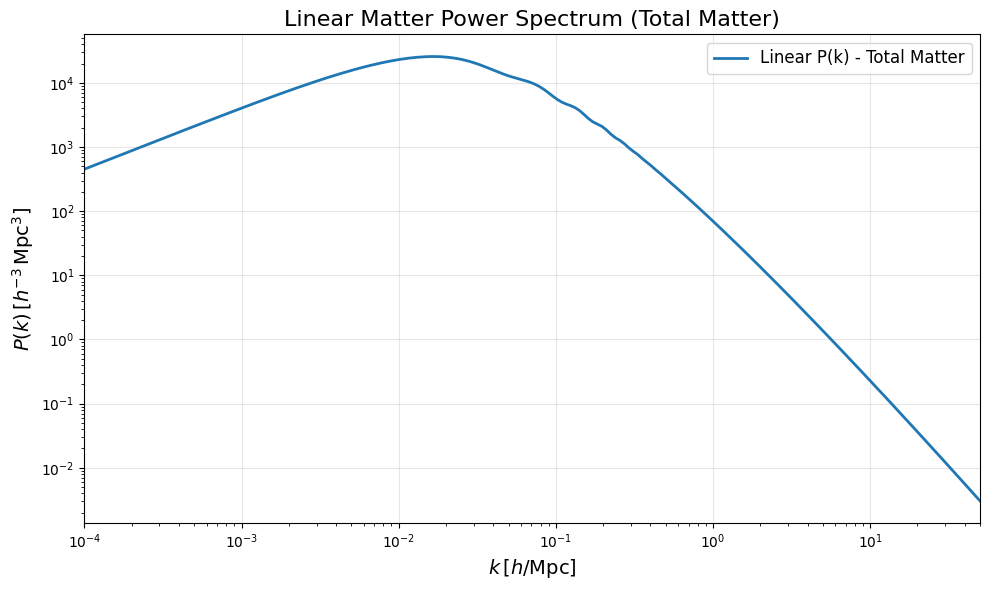

In [3]:
# -*- coding: utf-8 -*-
"""
Linear Matter Power Spectrum Generator (Total Matter only) using baccoemu
"""
import warnings
warnings.filterwarnings("ignore")  # <-- Suppress all warnings
import numpy as np
import matplotlib.pyplot as plt
import baccoemu

def generate_linear_power_spectrum():
    """
    Generate linear total matter power spectrum using baccoemu emulator
    """
    # Initialize the emulator
    emulator = baccoemu.Matter_powerspectrum()

    # Define wavenumber array (k in h/Mpc)
    k = np.logspace(-4, np.log10(50), 200)  # 200 points from 0.0001 to 50 h/Mpc

    # Define cosmological parameters (fiducial ΛCDM cosmology)
    params = {
        'omega_cold'    : 0.315,
        'sigma8_cold'   : 0.83,
        'omega_baryon'  : 0.05,
        'ns'            : 0.96,
        'hubble'        : 0.67,
        'neutrino_mass' : 0.0,
        'w0'            : -1.0,
        'wa'            : 0.0,
        'expfactor'     : 1.0
    }

    # Compute total matter power spectrum (cold=False)
    k_out, pk_lin_total = emulator.get_linear_pk(k=k, cold=False, **params)

    return k_out, pk_lin_total

def plot_linear_power_spectrum(k, pk_total):
    """
    Plot the linear total matter power spectrum
    """
    plt.figure(figsize=(10, 6))

    # Plot only total matter (solid line)
    plt.loglog(k, pk_total, label='Linear P(k) - Total Matter', linewidth=2)

    # Formatting
    plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$', fontsize=14)
    plt.ylabel(r'$P(k) \, [h^{-3}\,\mathrm{Mpc}^3]$', fontsize=14)
    plt.title('Linear Matter Power Spectrum (Total Matter)', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(1e-4, 50)

    plt.tight_layout()
    plt.show()

def main():
    """
    Main function to generate and display total matter power spectrum
    """
    print("Generating total matter linear power spectrum using baccoemu...")

    # Generate the power spectrum
    k, pk_total = generate_linear_power_spectrum()

    # Print some basic info
    print(f"k range: {k.min():.1e} to {k.max():.1e} h/Mpc")
    print(f"Number of k points: {len(k)}")
    print(f"Peak power (total matter): {pk_total.max():.1e} h^-3 Mpc^3")

    # Plot the results
    plot_linear_power_spectrum(k, pk_total)

    return k, pk_total

if __name__ == "__main__":
    k, pk_total = main()